# Iris - AutoGluon

### Importar Bibliotecas

In [1]:
from autogluon.tabular import TabularPredictor
from sklearn.datasets import load_iris
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Carregar Dados

In [2]:
# Carregar o dataset Iris a partir do scikit-learn
iris = load_iris()

# Criar DataFrame com as variáveis explicativas
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Adicionar a variável alvo
df["target"] = iris.target

# Visualizar as primeiras linhas
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Análise Exploratória

### Informação geral dos dados

In [8]:
print("Dimensão:", df.shape)

print("\nClasses:")
df["target"].value_counts()

print("\nResumo estatístico:")
df.describe()

Dimensão: (150, 5)

Classes:

Resumo estatístico:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### Valores em Falta

In [4]:
print("Valores em falta por coluna:")
df.isnull().sum()

Valores em falta por coluna:


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

### Distribuição das Classes

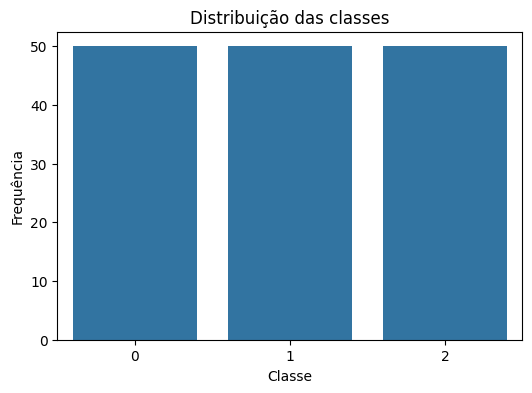

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)
plt.title("Distribuição das classes")
plt.xlabel("Classe")
plt.ylabel("Frequência")
plt.show()

A distribuição das classes no dataset revela um equilíbrio perfeito entre as três espécies (setosa, versicolor e virginica), o que elimina enviesamentos na aprendizagem e favorece uma avaliação mais justa do desempenho dos modelos.

### Distribuição das Variáveis

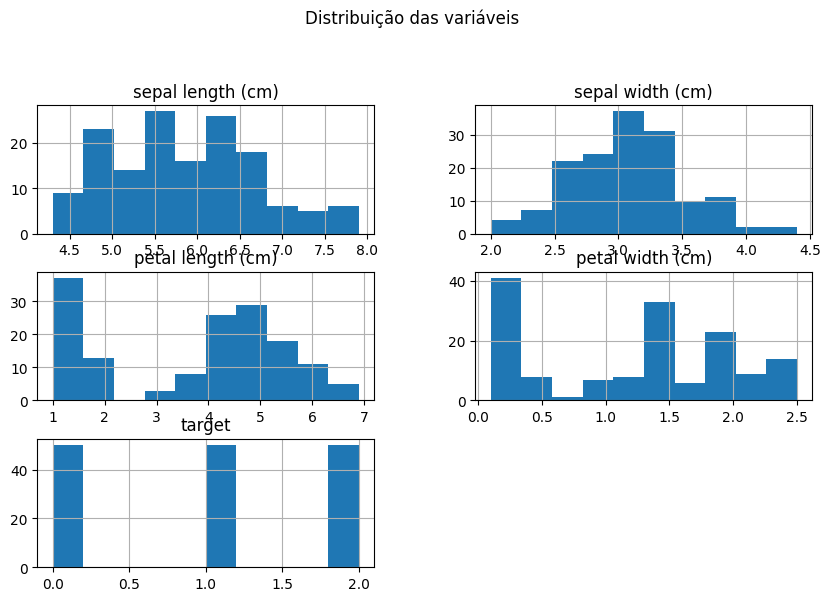

In [12]:
df.hist(figsize=(10,6))
plt.suptitle("Distribuição das variáveis", y=1.04)
plt.show()

A distribuição das variáveis evidencia padrões distintos, destacando-se as variáveis petal_length e petal_width pela sua maior capacidade de separação entre classes, ao contrário das variáveis sepal, que apresentam maior sobreposição e menor poder discriminativo

### Relação entre as Variáveis

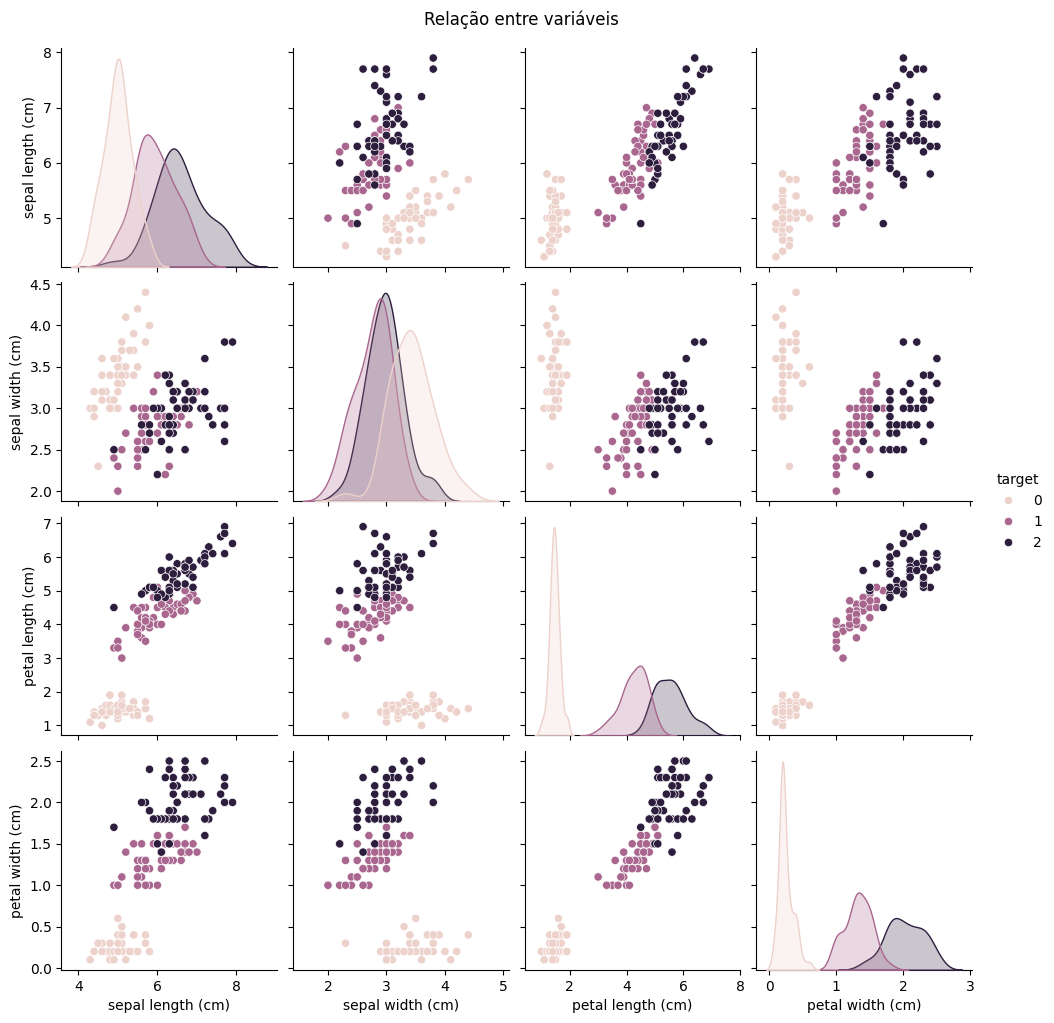

In [13]:
sns.pairplot(df, hue="target")
plt.suptitle("Relação entre variáveis", y=1.02)
plt.show()

A análise da relação entre variáveis evidencia uma clara separação entre as espécies, sobretudo nas variáveis petal_length e petal_width, onde os grupos se distinguem quase sem sobreposição, ao contrário das variáveis sepal, que apresentam maior dispersão e interseção entre classes.

### Correlação entre as Variáveis

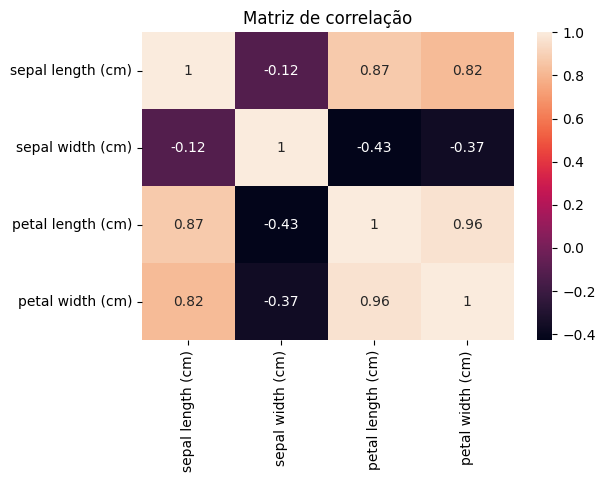

In [14]:
corr = df.drop("target", axis=1).corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)
plt.title("Matriz de correlação")
plt.show()

A matriz de correlação evidencia uma forte relação positiva entre petal_length e petal_width, indicando elevada redundância de informação, enquanto sepal_width apresenta correlações fracas ou negativas com as restantes variáveis, revelando menor relevância para a distinção entre classes.

### Conclusões da análise exploratória

- O dataset não apresenta valores em falta, garantindo qualidade dos dados.  
- As classes encontram-se equilibradas, evitando enviesamentos.  
- As variáveis *petal_length* e *petal_width* têm elevado poder discriminativo.  
- As variáveis *sepal* apresentam maior sobreposição entre classes.  
- Existe forte correlação entre *petal_length* e *petal_width*.  
- O problema apresenta baixa complexidade e elevada separabilidade.  
- Modelos mais complexos podem não trazer ganhos relevantes.  

## Dividir a Base de Dados em Treino e Teste

In [15]:
train_data = df.sample(frac=0.8, random_state=42)
test_data = df.drop(train_data.index)

print("Treino:", train_data.shape)
print("Teste:", test_data.shape)

Treino: (120, 5)
Teste: (30, 5)


## Treinar o AutoGlun

In [19]:
# Criar o predictor
predictor = TabularPredictor(
    label="target",
    problem_type="multiclass"
).fit(
    train_data=train_data,
    presets="best_v150",
    time_limit=60
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260327_200013"
Preset alias specified: 'best_v150' maps to 'best_quality_v150'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       3.91 GB / 15.73 GB (24.8%)
Disk Space Avail:   311.30 GB / 475.39 GB (65.5%)
Presets specified: ['best_v150']
Using hyperparameters preset: hyperparameters='zeroshot_2025_12_18_cpu'
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=8, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "C:\Users\anagil\Downloads\AutogluonModels\ag-20260327_200013"
Train Data Rows:    120
Train Data Columns: 4
Label Column:       target
Problem Type:       multicla

In [20]:
predictor = TabularPredictor(
    label="target",
    problem_type="multiclass"
).fit(
    train_data=train_data,
    presets="good",
    time_limit=60
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260327_200835"
Preset alias specified: 'good' maps to 'good_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       3.35 GB / 15.73 GB (21.3%)
Disk Space Avail:   311.29 GB / 475.39 GB (65.5%)
Presets specified: ['good']
Using hyperparameters preset: hyperparameters='light'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error durin

O AutoGluon realizou uma exploração extensa de múltiplas configurações de modelos, ajustando automaticamente o processo às limitações de memória e garantindo um desempenho elevado, embora essa complexidade adicional se revele desproporcional face à simplicidade do dataset Iris.

## Leaderboard

In [22]:
leaderboard = predictor.leaderboard(test_data, silent=True)
leaderboard

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetFastAI_BAG_L1_FULL,1.0,NaN,accuracy,0.241954,NaN,1.161143,0.241954,NaN,1.161143,1,True,4
1,WeightedEnsemble_L3_FULL,1.0,NaN,accuracy,0.261739,NaN,1.175129,0.019785,NaN,0.013986,3,True,6
2,WeightedEnsemble_L2_FULL,1.0,NaN,accuracy,0.273766,NaN,1.176862,0.031812,NaN,0.015718,2,True,5
3,NeuralNetFastAI_BAG_L1,NaN,0.983333,accuracy,NaN,0.124424,16.578519,NaN,0.124424,16.578519,1,False,1
4,WeightedEnsemble_L2,NaN,0.983333,accuracy,NaN,0.128448,16.594238,NaN,0.004024,0.015718,2,False,2
5,WeightedEnsemble_L3,NaN,0.983333,accuracy,NaN,0.130145,16.592505,NaN,0.005721,0.013986,3,False,3


Embora o leaderboard apresente apenas um conjunto reduzido de modelos, o AutoGluon explora internamente um número significativamente mais elevado de configurações, selecionando e apresentando apenas as soluções mais relevantes para análise.

Os resultados mostram que diferentes modelos atingem desempenho máximo, indicando que o dataset Iris é facilmente separável e não exige abordagens complexas para obter elevada precisão.

### Top 3 modelos e F1-score de cada um

In [31]:
top3_models = leaderboard["model"].head(3).tolist()
resultados_top3 = []

for model_name in top3_models:
    preds_model = predictor.predict(test_data, model=model_name)
    f1_model = f1_score(y_true, preds_model, average="weighted")
    
    resultados_top3.append({
        "Modelo": model_name,
        "F1_score": f1_model
    })

df_top3 = pd.DataFrame(resultados_top3).sort_values("F1_score", ascending=False)
print(df_top3)

                        Modelo  F1_score
0  NeuralNetFastAI_BAG_L1_FULL       1.0
1     WeightedEnsemble_L3_FULL       1.0
2     WeightedEnsemble_L2_FULL       1.0


A análise dos três melhores modelos revela que todos atingem um F1-score de 1.0, incluindo tanto modelos individuais como ensembles. Este resultado indica que o problema apresenta baixa complexidade e elevada separabilidade entre classes, permitindo que diferentes abordagens alcancem desempenho máximo sem ganhos adicionais decorrentes do aumento de complexidade.

### Gráfico dos 3 Melhores Modelos

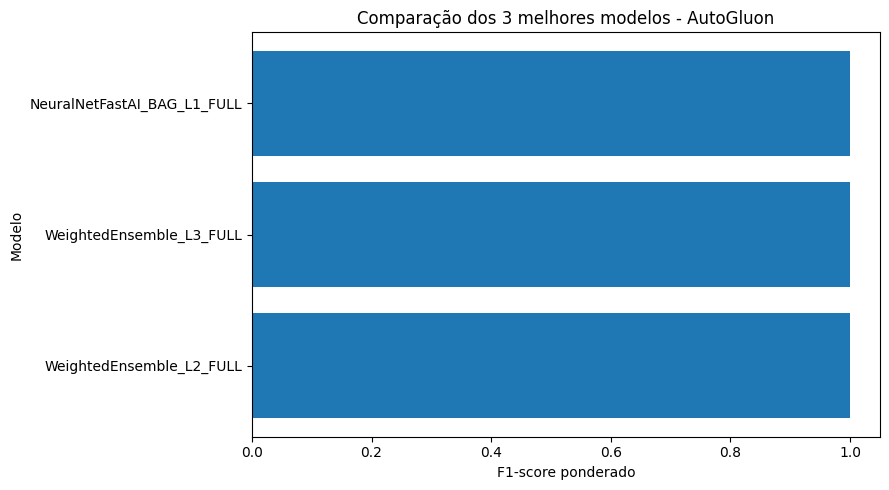

In [32]:
plt.figure(figsize=(9,5))
plt.barh(df_top3["Modelo"], df_top3["F1_score"])
plt.xlabel("F1-score ponderado")
plt.ylabel("Modelo")
plt.title("Comparação dos 3 melhores modelos - AutoGluon")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## O Melhor Modelo

In [41]:
# Melhor modelo
best_model = leaderboard.iloc[0]["model"]

print("\n=== Melhor modelo ===")
print(best_model)


=== Melhor modelo ===
NeuralNetFastAI_BAG_L1_FULL


In [23]:
performance = predictor.evaluate(test_data)
print(performance)

{'accuracy': 1.0, 'balanced_accuracy': np.float64(1.0), 'mcc': 1.0}


In [42]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Previsões do melhor modelo
best_predictions = predictor.predict(test_data, model=best_model)

# Valores reais
y_true = test_data["target"]

# F1-score ponderado
best_f1 = f1_score(y_true, best_predictions, average="weighted")

print("=== Performance do melhor modelo ===")
print("F1-score ponderado:", best_f1)
print("\nRelatório de classificação:")
print(classification_report(y_true, best_predictions))

=== Performance do melhor modelo ===
F1-score ponderado: 1.0

Relatório de classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



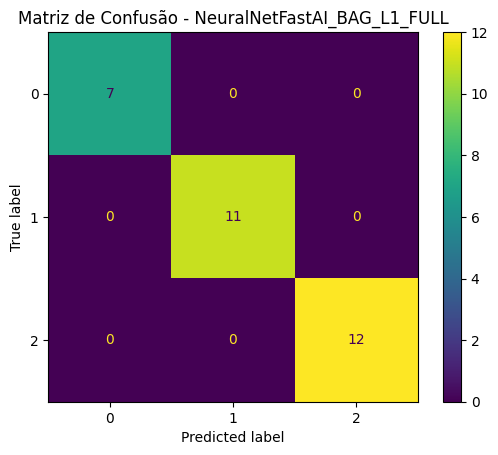

In [43]:
# Matriz de Confusão
cm = confusion_matrix(y_true, best_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title(f"Matriz de Confusão - {best_model}")
plt.show()

A matriz de confusão evidencia uma classificação perfeita em todas as classes, sem ocorrência de erros. No entanto, este resultado deve ser interpretado com cautela, uma vez que a elevada separabilidade do dataset Iris facilita significativamente o processo de classificação, não constituindo necessariamente um indicador da superioridade do modelo utilizado.

In [45]:
# Alguns modelos permitem ver a importância das variáveis
print("=== Importância das variáveis ===")

importance = predictor.feature_importance(test_data, model=best_model)
print(importance)

Computing feature importance via permutation shuffling for 4 features using 30 rows with 5 shuffle sets...
	0.91s	= Expected runtime (0.18s per shuffle set)


=== Importância das variáveis ===


	0.38s	= Actual runtime (Completed 5 of 5 shuffle sets)


                   importance    stddev   p_value  n  p99_high   p99_low
petal width (cm)     0.340000  0.086281  0.000458  5  0.517654  0.162346
petal length (cm)    0.300000  0.040825  0.000040  5  0.384059  0.215941
sepal width (cm)     0.040000  0.027889  0.016339  5  0.097423 -0.017423
sepal length (cm)    0.026667  0.027889  0.049650  5  0.084090 -0.030756


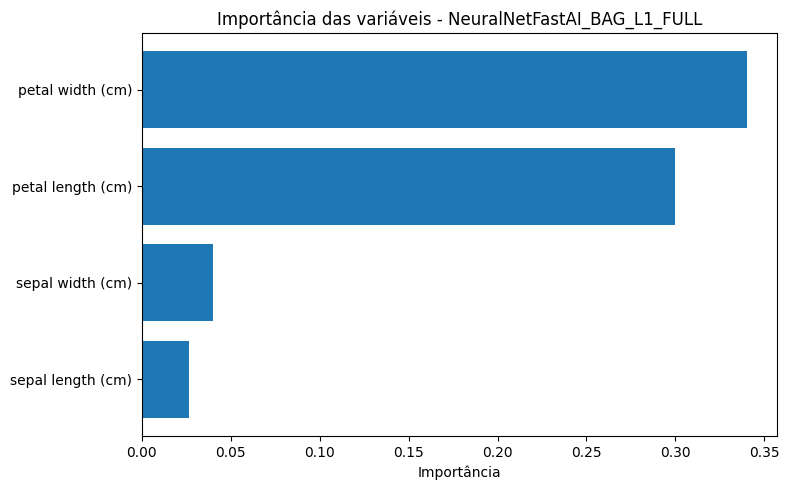

In [46]:
# Gráfico da importância das variáveis
importance_sorted = importance.sort_values("importance", ascending=True)

plt.figure(figsize=(8,5))
plt.barh(importance_sorted.index, importance_sorted["importance"])
plt.xlabel("Importância")
plt.title(f"Importância das variáveis - {best_model}")
plt.tight_layout()
plt.show()

### Config de 3 Modelos

In [2]:
# Definir apenas 3 famílias de modelos
hyperparameters_3 = {
    "GBM": [{}],        # LightGBM
    "CAT": [{}],        # CatBoost
    "NN_TORCH": [{}],   # Rede neuronal em PyTorch
}

predictor_3 = TabularPredictor(
    label="target",
    problem_type="multiclass"
).fit(
    train_data=train_data,
    hyperparameters=hyperparameters_3,
    time_limit=60,
    verbosity=2
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260409_131638"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       2.61 GB / 15.73 GB (16.6%)
Disk Space Avail:   318.96 GB / 475.39 GB (67.1%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models (TFMs) meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitr

In [3]:
leaderboard_3 = predictor_3.leaderboard(test_data, silent=True)
leaderboard_3

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,CatBoost,0.966667,0.958333,accuracy,0.061745,0.002115,9.107922,0.061745,0.002115,9.107922,1,True,2
1,NeuralNetTorch,0.966667,0.958333,accuracy,0.077396,0.008496,2.253487,0.077396,0.008496,2.253487,1,True,3
2,WeightedEnsemble_L2,0.966667,0.958333,accuracy,0.127741,0.003335,9.214494,0.065996,0.001220,0.106572,2,True,4
3,LightGBM,0.933333,0.916667,accuracy,0.060035,0.000571,0.460649,0.060035,0.000571,0.460649,1,True,1


Apesar de terem sido selecionadas três famílias de modelos, o AutoGluon gerou adicionalmente um modelo do tipo ensemble (WeightedEnsemble), que combina os modelos base com o objetivo de melhorar o desempenho final.

In [6]:
from sklearn.metrics import f1_score

y_true = test_data["target"]

resultados = []

for model_name in leaderboard_3["model"]:
    preds = predictor_3.predict(test_data, model=model_name)
    f1 = f1_score(y_true, preds, average="weighted")
    
    resultados.append({
        "Modelo": model_name,
        "F1_score": f1
    })

df_resultados = pd.DataFrame(resultados).sort_values("F1_score", ascending=False)

df_resultados

,Modelo,F1_score
0,CatBoost,0.966667
1,NeuralNetTorch,0.966667
2,WeightedEnsemble_L2,0.966667
3,LightGBM,0.933333


O AutoGluon foi configurado para testar apenas três famílias de modelos (GBM, Random Forest e redes neuronais), permitindo uma comparação mais controlada entre abordagens distintas, sem comprometer a capacidade de otimização automática.

### Config com Ficheiro

In [7]:
import json

with open("config_autogluon.json") as f:
    config = json.load(f)

print(config)

{'GBM': {}, 'CAT': {}, 'NN_TORCH': {}}


In [8]:
predictor = TabularPredictor(
    label="target",
    problem_type="multiclass"
).fit(
    train_data=train_data,
    hyperparameters=config,   # aqui está o JSON
    time_limit=60,
    verbosity=2
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260409_144052"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       3.12 GB / 15.73 GB (19.8%)
Disk Space Avail:   318.66 GB / 475.39 GB (67.0%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models (TFMs) meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitr

In [10]:
leaderboard = predictor.leaderboard(test_data, silent=True)
leaderboard

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,CatBoost,0.966667,0.958333,accuracy,0.003384,0.001948,0.435205,0.003384,0.001948,0.435205,1,True,2
1,WeightedEnsemble_L2,0.966667,0.958333,accuracy,0.006166,0.005648,0.478135,0.002782,0.003700,0.042931,2,True,4
2,NeuralNetTorch,0.966667,0.958333,accuracy,0.006724,0.004056,0.945959,0.006724,0.004056,0.945959,1,True,3
3,LightGBM,0.933333,0.916667,accuracy,0.002008,0.002645,1.153965,0.002008,0.002645,1.153965,1,True,1


In [12]:
y_true = test_data["target"]
resultados = []

for model_name in leaderboard["model"]:
    preds = predictor.predict(test_data, model=model_name)
    
    f1 = f1_score(y_true, preds, average="weighted")
    
    resultados.append({
        "Modelo": model_name,
        "F1_score": f1
    })

df_resultados = pd.DataFrame(resultados).sort_values(by="F1_score", ascending=False)

df_resultados

,Modelo,F1_score
0,CatBoost,0.966667
1,WeightedEnsemble_L2,0.966667
2,NeuralNetTorch,0.966667
3,LightGBM,0.933333


## AutoGluon

A aplicação do AutoGluon ao dataset Iris permitiu identificar automaticamente um conjunto de modelos com desempenho máximo, destacando-se o modelo *NeuralNetFastAI_BAG_L1_FULL*, que atingiu valores perfeitos em todas as métricas avaliadas, incluindo accuracy, F1-score ponderado e matriz de confusão sem erros. Estes resultados evidenciam a eficácia da ferramenta na exploração do espaço de modelos e na construção de soluções robustas de forma automatizada.

A análise da importância das variáveis confirma a relevância das características *petal_length* e *petal_width*, previamente identificadas na análise exploratória como determinantes para a distinção entre classes, reforçando a consistência entre os dados e o modelo gerado. Adicionalmente, a ausência de diferenças de desempenho entre os três melhores modelos indica uma convergência para soluções equivalentes, incluindo modelos individuais e ensembles.

No entanto, estes resultados devem ser interpretados com cuidado, uma vez que o dataset Iris apresenta elevada separabilidade entre classes e reduzida complexidade, o que facilita a obtenção de desempenhos máximos independentemente do modelo utilizado. Assim, o principal contributo do AutoGluon neste contexto não reside na obtenção de melhores resultados, mas na eficiência do processo automático de modelação e comparação de modelos, sendo a sua utilização particularmente mais relevante em problemas de maior complexidade.